Лучшие параметры дерева: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt'}
Метрики дерева до фильтрации: {'accuracy': 0.8584474885844748, 'precision': 0.9051094890510949, 'recall': 0.8732394366197183, 'f1': 0.8888888888888888}
Важность признаков (дерево):
 Amount          0.322093
Sales Person    0.259296
Product         0.259060
Country         0.159551
dtype: float64
Метрики дерева после фильтрации: {'accuracy': 0.882800608828006, 'precision': 0.9011494252873563, 'recall': 0.92018779342723, 'f1': 0.9105691056910569}
Лучшие параметры леса: {'max_depth': None, 'n_estimators': 200}
Метрики леса до фильтрации: {'accuracy': 0.9269406392694064, 'precision': 0.9543269230769231, 'recall': 0.931924882629108, 'f1': 0.9429928741092637}
Метрики леса после фильтрации: {'accuracy': 0.9223744292237442, 'precision': 0.9496402877697842, 'recall': 0.9295774647887324, 'f1': 0.9395017793594306}
Мучшее k: {'n_neighbors': 1}
Метрики knn до фильтрации: {'accuracy': 0.9512937595129376, 'pr

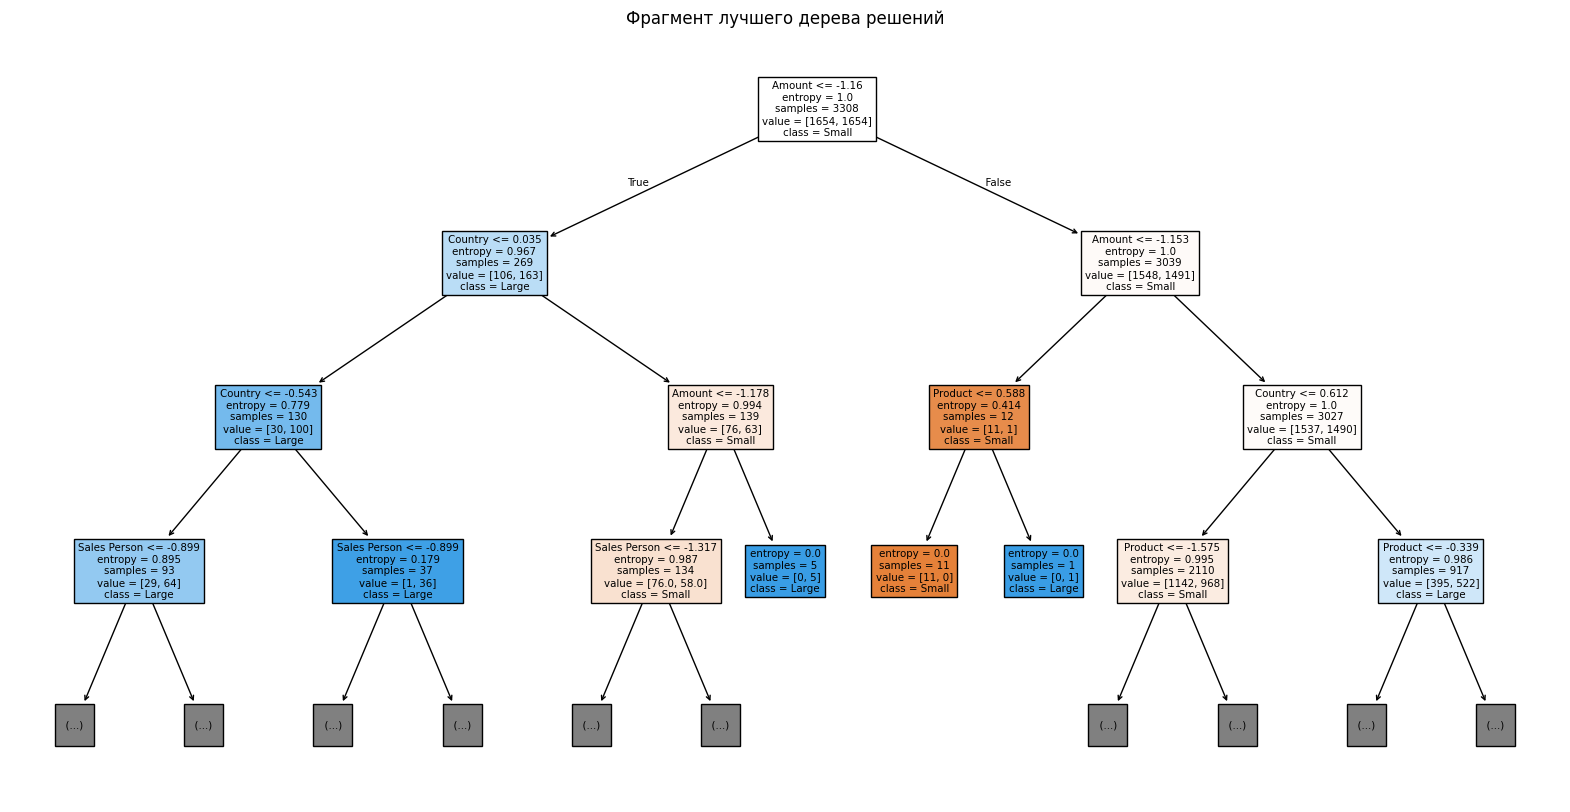

Сравнение моделей на тестовой выборке:
            Model  Accuracy  F1-Score
0  Decision Tree  0.882801  0.910569
1  Random Forest  0.922374  0.939502
2            kNN  0.891933  0.914355


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import RandomOverSampler

# 1. считывание данных
df = pd.read_csv('/content/drive/MyDrive/Учёба/8 семестр/ТИИ/Chocolate Sales (2).csv')

# 2. подготовка данных
# описание датасета
"""
Датасет содержит данные о мировых продажах шоколада.
Цель — классификация сделок на крупные и мелкие (Is_Large: > 100 коробок).

Таблица признаков:
Признак            Описание                          Единицы измерения
Sales Person       Имя продавца                      Категория
Country            Страна поставки                   Категория
Product            Тип продукта                      Категория
Amount             Сумма сделки                      Доллары США
Boxes Shipped      Количество коробок                Штуки
Is_Large           Целевой признак (таргет)          0 или 1
"""

# предобработка (подчистка данных)
df['Amount'] = df['Amount'].replace(r'[\$,]', '', regex=True).astype(float)
df['Is_Large'] = (df['Boxes Shipped'] > 100).astype(int)

# убираем дату и исходное кол-во коробок
df_clean = df.drop(['Date', 'Boxes Shipped'], axis=1).dropna()

# кодирование категориальных признаков
le = LabelEncoder()
cat_cols = ['Sales Person', 'Country', 'Product']
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

x = df_clean.drop('Is_Large', axis=1)
y = df_clean['Is_Large']

# нормализация данных (обязательна для knn и полезна для сравнения)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# разбиение выборки
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

# устранение дисбаланса
ros = RandomOverSampler(random_state=42)
x_train_res, y_train_res = ros.fit_resample(x_train, y_train)

# функция для вывода метрик
def get_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred)
    }

# 3. дерево решений
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='f1')
dt_grid.fit(x_train_res, y_train_res)

best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(x_test)

print("Лучшие параметры дерева:", dt_grid.best_params_)
print("Метрики дерева до фильтрации:", get_metrics(y_test, y_pred_dt))

# важность признаков
importances = pd.Series(best_dt.feature_importances_, index=x.columns).sort_values(ascending=False)
print("Важность признаков (дерево):\n", importances)

# фильтрация признаков (порог > 0.05)
dt_features = importances[importances > 0.05].index.tolist()
x_train_dt_filt = pd.DataFrame(x_train_res, columns=x.columns)[dt_features]
x_test_dt_filt = pd.DataFrame(x_test, columns=x.columns)[dt_features]

dt_grid_filt = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5)
dt_grid_filt.fit(x_train_dt_filt, y_train_res)
y_pred_dt_filt = dt_grid_filt.best_estimator_.predict(x_test_dt_filt)

print("Метрики дерева после фильтрации:", get_metrics(y_test, y_pred_dt_filt))

# 4. случайный лес
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5)
rf_grid.fit(x_train_res, y_train_res)

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(x_test)

print("Лучшие параметры леса:", rf_grid.best_params_)
print("Метрики леса до фильтрации:", get_metrics(y_test, y_pred_rf))

# фильтрация признаков для леса
rf_importances = pd.Series(best_rf.feature_importances_, index=x.columns).sort_values(ascending=False)
rf_features = rf_importances[rf_importances > 0.05].index.tolist()
x_train_rf_filt = pd.DataFrame(x_train_res, columns=x.columns)[rf_features]
x_test_rf_filt = pd.DataFrame(x_test, columns=x.columns)[rf_features]

rf_grid_filt = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5)
rf_grid_filt.fit(x_train_rf_filt, y_train_res)
y_pred_rf_filt = rf_grid_filt.best_estimator_.predict(x_test_rf_filt)

print("Метрики леса после фильтрации:", get_metrics(y_test, y_pred_rf_filt))

# 5. метод ближайших соседей
knn_params = {'n_neighbors': range(1, 21)}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5)
knn_grid.fit(x_train_res, y_train_res)

print("Мучшее k:", knn_grid.best_params_)
print("Метрики knn до фильтрации:", get_metrics(y_test, knn_grid.best_estimator_.predict(x_test)))

# фильтрация для knn через корреляцию (т.к. нет важности признаков)
knn_features = df_clean.corr().abs()['Is_Large'].sort_values(ascending=False).iloc[1:4].index.tolist()
x_train_knn_filt = pd.DataFrame(x_train_res, columns=x.columns)[knn_features]
x_test_knn_filt = pd.DataFrame(x_test, columns=x.columns)[knn_features]

knn_grid_filt = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5)
knn_grid_filt.fit(x_train_knn_filt, y_train_res)
print("Метрики knn после фильтрации:", get_metrics(y_test, knn_grid_filt.best_estimator_.predict(x_test_knn_filt)))

# 7. оценка качества и визуализация
# визуализация дерева
plt.figure(figsize=(20, 10))
plot_tree(dt_grid_filt.best_estimator_, feature_names=dt_features, class_names=['Small', 'Large'], filled=True, max_depth=3)
plt.title('Фрагмент лучшего дерева решений')
plt.show()

# итоговое сравнение на тестовой выборке
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'kNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt_filt),
        accuracy_score(y_test, y_pred_rf_filt),
        accuracy_score(y_test, knn_grid_filt.best_estimator_.predict(x_test_knn_filt))
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_dt_filt),
        f1_score(y_test, y_pred_rf_filt),
        f1_score(y_test, knn_grid_filt.best_estimator_.predict(x_test_knn_filt))
    ]
})

print("Сравнение моделей на тестовой выборке:\n", results)